In [14]:
import pandas as pd

# Carregar o dataset (assumindo que 'vendas_com_outliers.csv' foi gerado)
df_vendas = pd.read_csv("vendas_com_outliers.csv")

# 1. Calcular Q1 (25º percentil) e Q3 (75º percentil)
Q1 = df_vendas["Vendas"].quantile(0.25)
Q3 = df_vendas["Vendas"].quantile(0.75)

# 2. Calcular o Intervalo Interquartil (IQR)
IQR = Q3 - Q1

# 3. Calcular os Limites Superior e Inferior
limite_inferior = Q1 - (1.5 * IQR)
limite_superior = Q3 + (1.5 * IQR)

print(f"Q1: {Q1:.2f}")
print(f"Q3: {Q3:.2f}")
print(f"IQR: {IQR:.2f}")
print(f"Limite Inferior: {limite_inferior:.2f}")
print(f"Limite Superior: {limite_superior:.2f}")

# 4. Identificar Outliers Superiores e Inferiores
outliers_superiores = df_vendas[df_vendas["Vendas"] > limite_superior]
outliers_inferiores = df_vendas[df_vendas["Vendas"] < limite_inferior]

print("\n--- Outliers Superiores ---")
if not outliers_superiores.empty:
    print(outliers_superiores.sort_values(by="Vendas", ascending=False))
else:
    print("Nenhum outlier superior encontrado.")

print("\n--- Outliers Inferiores ---")
if not outliers_inferiores.empty:
    print(outliers_inferiores.sort_values(by="Vendas", ascending=True))
else:
    print("Nenhum outlier inferior encontrado.")

Q1: 130.75
Q3: 165.25
IQR: 34.50
Limite Inferior: 79.00
Limite Superior: 217.00

--- Outliers Superiores ---
    ID_Produto     Produto  Vendas  Categoria
13          14  Produto_14     464  Alimentos
39          40  Produto_40     436     Livros
59          60  Produto_60     361   Serviços

--- Outliers Inferiores ---
    ID_Produto     Produto  Vendas  Categoria
12          13  Produto_13      45   Serviços
41          42  Produto_42      47  Alimentos
74          75  Produto_75      71  Alimentos


In [13]:
import pandas as pd

# Carregar o dataset
df_satisfacao = pd.read_csv("satisfacao_clientes.csv")

# 1. Calcular Q1 e Q3 para a coluna 'Avaliacao'
Q1_sat = df_satisfacao["Avaliacao"].quantile(0.25)
Q3_sat = df_satisfacao["Avaliacao"].quantile(0.75)

# 2. Calcular o IQR
IQR_sat = Q3_sat - Q1_sat

# 3. Calcular os Limites Superior e Inferior
limite_inferior_sat = Q1_sat - (1.5 * IQR_sat)
limite_superior_sat = Q3_sat + (1.5 * IQR_sat)

print(f"Q1 (Avaliacoes): {Q1_sat:.2f}")
print(f"Q3 (Avaliacoes): {Q3_sat:.2f}")
print(f"IQR (Avaliacoes): {IQR_sat:.2f}")
print(f"Limite Inferior (Avaliacoes): {limite_inferior_sat:.2f}")
print(f"Limite Superior (Avaliacoes): {limite_superior_sat:.2f}")

# 4. Identificar e ordenar Outliers
outliers_superiores_sat = df_satisfacao[df_satisfacao["Avaliacao"] > limite_superior_sat].sort_values(by="Avaliacao", ascending=False)
outliers_inferiores_sat = df_satisfacao[df_satisfacao["Avaliacao"] < limite_inferior_sat].sort_values(by="Avaliacao", ascending=True)

print("\n--- Outliers Superiores (Avaliacoes de Satisfação) ---")
if not outliers_superiores_sat.empty:
    print(outliers_superiores_sat)
else:
    print("Nenhum outlier superior de Avaliacao de satisfação encontrado.")

print("\n--- Outliers Inferiores (Avaliacoes de Satisfação) ---")
if not outliers_inferiores_sat.empty:
    print(outliers_inferiores_sat)
else:
    print("Nenhum outlier inferior de Avaliacao de satisfação encontrado.")

Q1 (Avaliacoes): 6.00
Q3 (Avaliacoes): 9.00
IQR (Avaliacoes): 3.00
Limite Inferior (Avaliacoes): 1.50
Limite Superior (Avaliacoes): 13.50

--- Outliers Superiores (Avaliacoes de Satisfação) ---
Nenhum outlier superior de Avaliacao de satisfação encontrado.

--- Outliers Inferiores (Avaliacoes de Satisfação) ---
    ID_Cliente  Avaliacao
26          27          1


Matplotlib is building the font cache; this may take a moment.


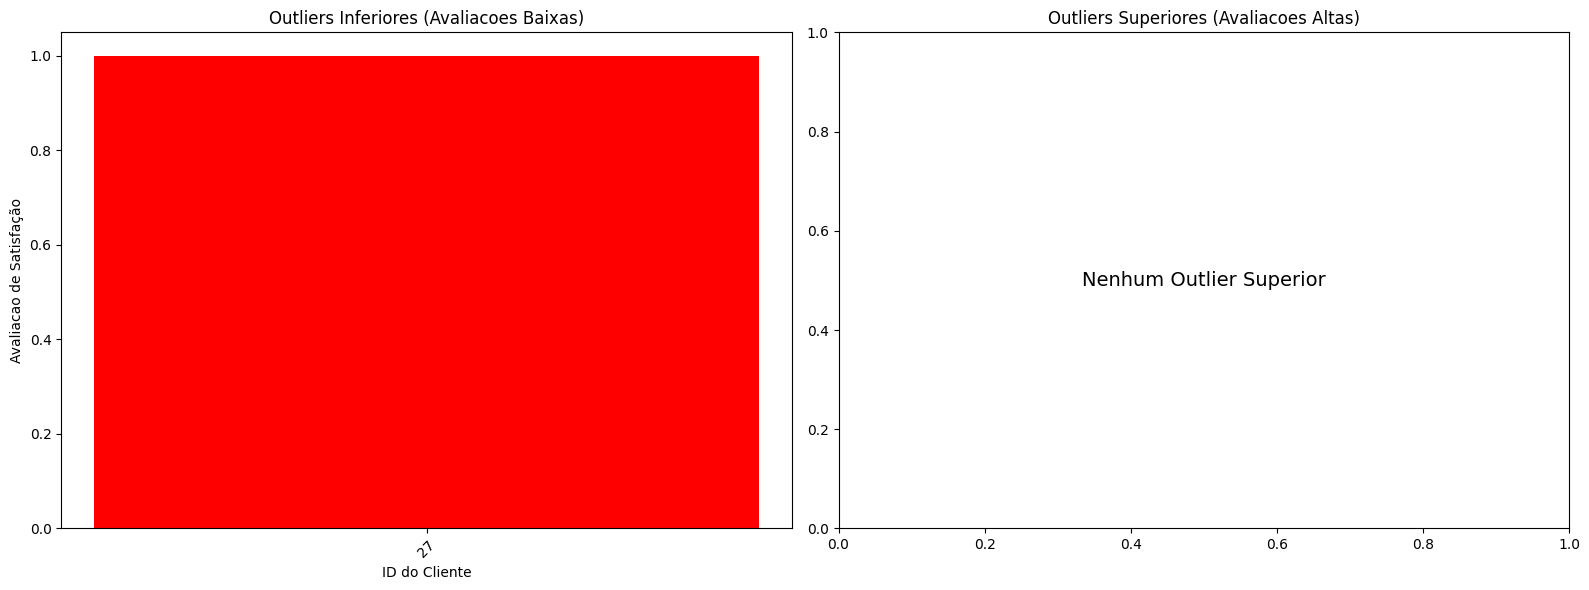

In [12]:
import matplotlib.pyplot as plt
import pandas as pd

# Re-executar o cálculo dos outliers para garantir que as variáveis existam
df_satisfacao = pd.read_csv("satisfacao_clientes.csv")
Q1_sat = df_satisfacao["Avaliacao"].quantile(0.25)
Q3_sat = df_satisfacao["Avaliacao"].quantile(0.75)
IQR_sat = Q3_sat - Q1_sat
limite_inferior_sat = Q1_sat - (1.5 * IQR_sat)
limite_superior_sat = Q3_sat + (1.5 * IQR_sat)
outliers_superiores_sat = df_satisfacao[df_satisfacao["Avaliacao"] > limite_superior_sat].sort_values(by="Avaliacao", ascending=False)
outliers_inferiores_sat = df_satisfacao[df_satisfacao["Avaliacao"] < limite_inferior_sat].sort_values(by="Avaliacao", ascending=True)

# Criação do painel de gráficos
fig, axes = plt.subplots(1, 2, figsize=(16, 6)) # Aumentei o figsize para melhor visualização

# Gráfico de Outliers Inferiores
if not outliers_inferiores_sat.empty:
    axes[0].bar(outliers_inferiores_sat["ID_Cliente"].astype(str), outliers_inferiores_sat["Avaliacao"], color="red")
    axes[0].set_title("Outliers Inferiores (Avaliacoes Baixas)")
    axes[0].set_xlabel("ID do Cliente")
    axes[0].set_ylabel("Avaliacao de Satisfação")
    axes[0].tick_params(axis="x", rotation=45)
else:
    axes[0].text(0.5, 0.5, "Nenhum Outlier Inferior", horizontalalignment="center", verticalalignment="center", transform=axes[0].transAxes, fontsize=14)
    axes[0].set_title("Outliers Inferiores (Avaliacoes Baixas)")

# Gráfico de Outliers Superiores
if not outliers_superiores_sat.empty:
    axes[1].bar(outliers_superiores_sat["ID_Cliente"].astype(str), outliers_superiores_sat["Avaliacao"], color="green")
    axes[1].set_title("Outliers Superiores (Avaliacoes Altas)")
    axes[1].set_xlabel("ID do Cliente")
    axes[1].set_ylabel("Avaliacao de Satisfação")
    axes[1].tick_params(axis="x", rotation=45)
else:
    axes[1].text(0.5, 0.5, "Nenhum Outlier Superior", horizontalalignment="center", verticalalignment="center", transform=axes[1].transAxes, fontsize=14)
    axes[1].set_title("Outliers Superiores (Avaliacoes Altas)")

plt.tight_layout() # Ajusta o layout para evitar sobreposição
plt.show()